# 12 — Multivariate Statistics: PCA and Factor Analysis
**References:** Pearson (1901) · Hotelling (1933) · Jolliffe (2002) · Spearman (1904)

## Narrative thread
```
Curse of dimensionality -> PCA: variance decomposition -> Biplots -> Factor analysis -> Clustering
```

## The curse of dimensionality

In high dimensions:
- Distance concentrates: all points become equidistant
- Volumes become sparse: exponentially more data needed to fill space
- Correlations become spurious: with $p$ variables and $n$ observations, $p^2/2$ pairwise correlations

**Solution:** reduce to a lower-dimensional representation that captures most variation.

## Principal Component Analysis (PCA)

**Goal:** find $k < p$ linear combinations of the original variables that capture the
most variance, and are mutually uncorrelated.

**Algorithm:**
1. Standardize: $\tilde{X} = (X - \bar{X}) / s$ (if variables on different scales)
2. Compute covariance matrix $\Sigma = \frac{1}{n-1}\tilde{X}^\top \tilde{X}$
3. Eigendecompose: $\Sigma = V\Lambda V^\top$ where $\Lambda = \text{diag}(\lambda_1 \geq \lambda_2 \geq \cdots)$
4. $k$-th principal component: $z_k = \tilde{X}v_k$ (scores = projection onto eigenvector $v_k$)

**Variance explained:**
$$\text{PVE}_k = \frac{\lambda_k}{\sum_j \lambda_j} \qquad \text{Cumulative PVE} = \frac{\sum_{j=1}^k \lambda_j}{\sum_j \lambda_j}$$

**Choosing $k$:** scree plot (elbow), Kaiser rule ($\lambda_k > 1$), or 80-90% cumulative PVE.

## PCA vs Factor Analysis

| | PCA | Factor Analysis |
|---|---|---|
| Goal | Maximize variance explained | Model latent structure |
| Interpretation | Mathematical rotation | Factors have substantive meaning |
| Error | None (exact decomposition) | Unique variances per variable |
| Use case | Dimensionality reduction, visualization | Construct validation, latent traits |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

PCA: Variance explained
PC      Eigenvalue      PVE   Cumulative
------------------------------------------
PC1         3.4100   42.48%       42.48%
PC2         2.4571   30.61%       73.10%
PC3         1.7357   21.62%       94.72%
PC4         0.2383    2.97%       97.69%
PC5         0.0961    1.20%       98.89%
PC6         0.0405    0.50%       99.39%
PC7         0.0358    0.45%       99.84%
PC8         0.0131    0.16%      100.00%


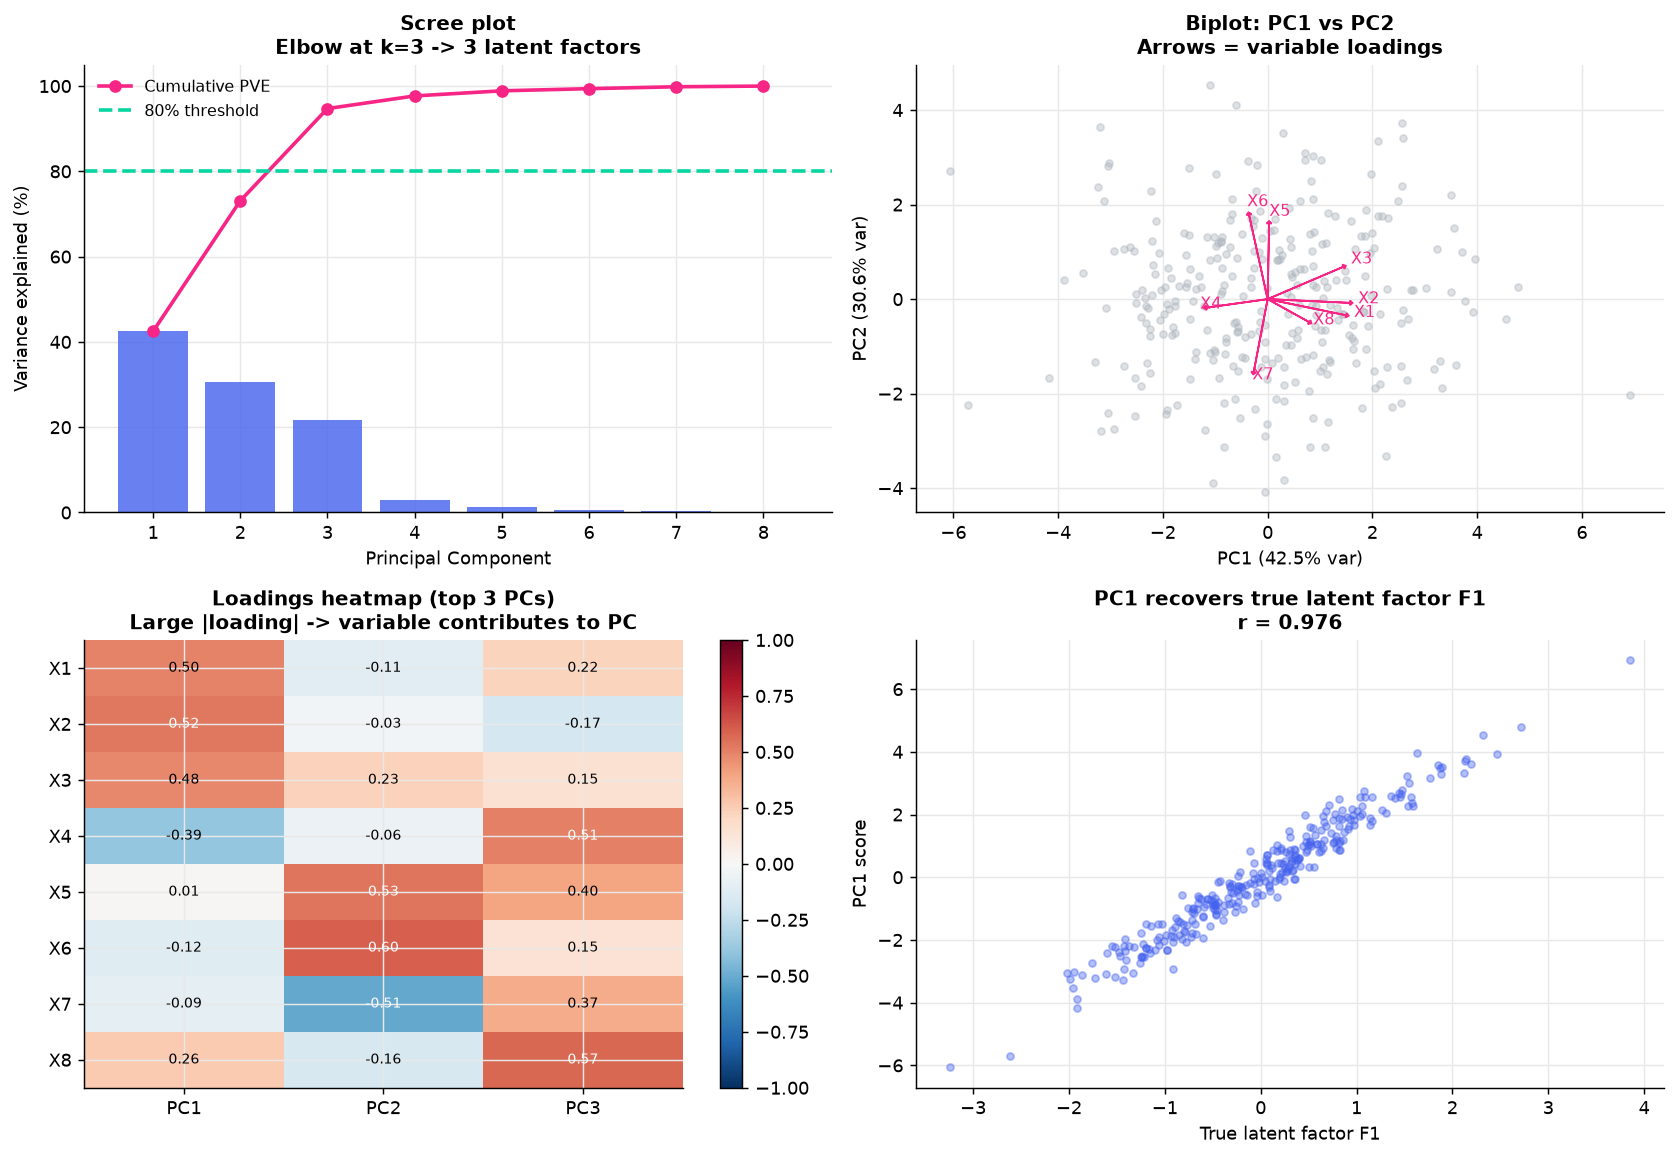

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Dataset: wine quality (UCI) or synthetic high-dimensional data ─────────
np.random.seed(42)
n_obs, p_orig = 300, 8

# Latent factor structure: 3 true factors
F1 = np.random.normal(0, 1, n_obs)   # e.g. "size"
F2 = np.random.normal(0, 1, n_obs)   # e.g. "quality"
F3 = np.random.normal(0, 1, n_obs)   # e.g. "age"

# Observed variables = loadings * factors + noise
X_raw = np.column_stack([
    0.9*F1 + 0.2*F2 + 0.1*np.random.normal(0,1,n_obs),
    0.8*F1 - 0.3*F2 + 0.1*np.random.normal(0,1,n_obs),
    0.7*F1 + 0.4*F3 + 0.2*np.random.normal(0,1,n_obs),
    -0.5*F1 + 0.7*F2 + 0.1*np.random.normal(0,1,n_obs),
    0.3*F2 + 0.8*F3 + 0.1*np.random.normal(0,1,n_obs),
    -0.2*F1 + 0.6*F3 + 0.2*np.random.normal(0,1,n_obs),
    0.5*F2 - 0.5*F3 + 0.3*np.random.normal(0,1,n_obs),
    0.4*F1 + 0.4*F2 + 0.4*np.random.normal(0,1,n_obs),
])
feat_names = [f'X{i+1}' for i in range(p_orig)]

# Standardize and fit PCA
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)
pca = PCA()
scores = pca.fit_transform(X_sc)

pve = pca.explained_variance_ratio_
cum_pve = np.cumsum(pve)

print('PCA: Variance explained')
print(f'{"PC":<5} {"Eigenvalue":>12} {"PVE":>8} {"Cumulative":>12}')
print('-'*42)
for i, (eig, p, cp) in enumerate(zip(pca.explained_variance_, pve, cum_pve)):
    print(f'PC{i+1:<3} {eig:>12.4f} {p*100:>7.2f}% {cp*100:>11.2f}%')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Scree plot
ax = axes[0,0]
ax.bar(range(1, p_orig+1), pve*100, color='#4361ee', alpha=0.8)
ax.plot(range(1, p_orig+1), cum_pve*100, 'o-', color='#f72585', lw=2, label='Cumulative PVE')
ax.axhline(80, color='#06d6a0', lw=2, linestyle='--', label='80% threshold')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree plot\nElbow at k=3 -> 3 latent factors')
ax.legend(fontsize=9)

# Biplot (PC1 vs PC2)
ax2 = axes[0,1]
ax2.scatter(scores[:,0], scores[:,1], s=15, alpha=0.4, color='#adb5bd')
loadings = pca.components_.T
scale = 3
for j, fname in enumerate(feat_names):
    ax2.arrow(0, 0, loadings[j,0]*scale, loadings[j,1]*scale,
              head_width=0.1, head_length=0.05, fc='#f72585', ec='#f72585')
    ax2.text(loadings[j,0]*scale*1.1, loadings[j,1]*scale*1.1, fname, fontsize=9, color='#f72585')
ax2.set_xlabel(f'PC1 ({pve[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pve[1]*100:.1f}% var)')
ax2.set_title('Biplot: PC1 vs PC2\nArrows = variable loadings')

# Loadings heatmap
ax3 = axes[1,0]
load_mat = pca.components_[:3].T
im = ax3.imshow(load_mat, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax3.set_xticks(range(3)); ax3.set_xticklabels(['PC1','PC2','PC3'])
ax3.set_yticks(range(p_orig)); ax3.set_yticklabels(feat_names)
plt.colorbar(im, ax=ax3)
for i in range(p_orig):
    for j in range(3):
        ax3.text(j, i, f'{load_mat[i,j]:.2f}', ha='center', va='center', fontsize=8,
                 color='white' if abs(load_mat[i,j]) > 0.5 else 'black')
ax3.set_title('Loadings heatmap (top 3 PCs)\nLarge |loading| -> variable contributes to PC')

# PC1 recovers F1 (latent factor)
ax4 = axes[1,1]
ax4.scatter(F1, scores[:,0], s=15, alpha=0.4, color='#4361ee')
r = np.corrcoef(F1, scores[:,0])[0,1]
ax4.set_xlabel('True latent factor F1'); ax4.set_ylabel('PC1 score')
ax4.set_title(f'PC1 recovers true latent factor F1\nr = {r:.3f}')
plt.tight_layout()
plt.show()

## Clustering: k-means and hierarchical

When labels are unknown, **clustering** groups observations by similarity.

**k-means:** minimize within-cluster sum of squares
$$\min_{C_1,\ldots,C_k} \sum_{j=1}^k \sum_{i \in C_j} \|x_i - \mu_j\|^2$$

**Choosing k:** elbow plot (inertia), silhouette score, or gap statistic.

**Hierarchical clustering:** builds a dendrogram by successively merging
(agglomerative) or splitting (divisive) clusters. Linkage determines distance
between clusters: single (min), complete (max), average, Ward (minimize variance).

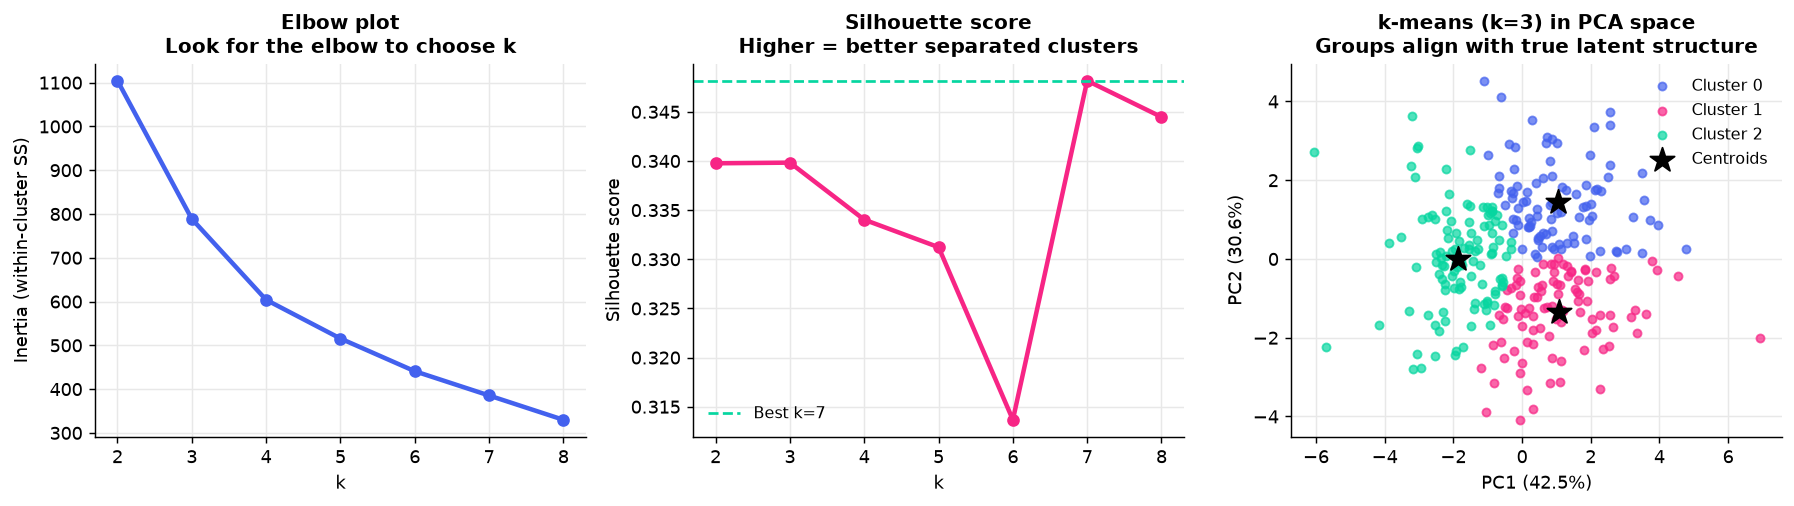

In [3]:
# ── k-means clustering ───────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster in 2D PCA space
X_2d = scores[:, :2]

# Elbow plot
inertias = []
sil_scores = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_2d)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_2d, labs))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ks, inertias, 'o-', color='#4361ee', lw=2.5)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow plot\nLook for the elbow to choose k')

axes[1].plot(ks, sil_scores, 'o-', color='#f72585', lw=2.5)
axes[1].axhline(max(sil_scores), color='#06d6a0', lw=1.5, linestyle='--',
                label=f'Best k={ks[np.argmax(sil_scores)]}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score\nHigher = better separated clusters')
axes[1].legend(fontsize=9)

# Final clustering with k=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km3.fit_predict(X_2d)
for lab, c in zip([0,1,2], ['#4361ee','#f72585','#06d6a0']):
    mask = labels == lab
    axes[2].scatter(X_2d[mask,0], X_2d[mask,1], s=20, alpha=0.7, color=c, label=f'Cluster {lab}')
axes[2].scatter(km3.cluster_centers_[:,0], km3.cluster_centers_[:,1],
                s=200, marker='*', color='black', zorder=5, label='Centroids')
axes[2].set_xlabel(f'PC1 ({pve[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pve[1]*100:.1f}%)')
axes[2].set_title('k-means (k=3) in PCA space\nGroups align with true latent structure')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()